# Bài tập: Mã hóa văn bản cho Luật Giao thông và Mức Xử phạt

Notebook này áp dụng các kỹ thuật mã hóa văn bản cho 2 nguồn dữ liệu:
1. **Luật Đường bộ 35/2024**: Văn bản pháp luật giao thông
2. **Nghị định 168/2024**: Mức xử phạt vi phạm giao thông

## Các kỹ thuật mã hóa:
- One-hot Encoding
- Count Vectorizing (Bag of Words)
- N-grams (Bigrams, Trigrams)
- Co-occurrence Matrix

In [1]:
# Import thư viện
import json
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Cấu hình hiển thị
plt.rcParams['font.family'] = 'DejaVu Sans'
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 1000)

## 1. Đọc và khám phá dữ liệu

In [2]:
# Đọc dữ liệu Luật Đường bộ
with open('../data/processed/preprocessed_data.json', 'r', encoding='utf-8') as f:
    law_data = json.load(f)

# Đọc dữ liệu Mức xử phạt
with open('../data/processed/nd168_penalties.json', 'r', encoding='utf-8') as f:
    penalty_data = json.load(f)

print("="*70)
print("THÔNG TIN DỮ LIỆU LUẬT ĐƯỜNG BỘ")
print("="*70)
print(f"Tổng số trang: {law_data['metadata']['total_pages']}")
print(f"Tổng số tokens: {law_data['metadata']['total_tokens']:,}")
print(f"Từ vựng duy nhất: {law_data['metadata']['unique_tokens']:,}")
print(f"Nguồn: {', '.join(law_data['metadata']['sources'])}")

print("\n" + "="*70)
print("THÔNG TIN DỮ LIỆU MỨC XỬ PHẠT")
print("="*70)
print(f"Tiêu đề: {penalty_data['title']}")
print(f"Nguồn: {penalty_data['source']}")
print(f"Tổng số điều: {penalty_data['total_articles']}")

THÔNG TIN DỮ LIỆU LUẬT ĐƯỜNG BỘ
Tổng số trang: 157
Tổng số tokens: 65,707
Từ vựng duy nhất: 2,537
Nguồn: Luật 35/2024, NĐ 168/2024

THÔNG TIN DỮ LIỆU MỨC XỬ PHẠT
Tiêu đề: Mức xử phạt vi phạm giao thông đường bộ
Nguồn: Nghị định 168/2024/NĐ-CP
Tổng số điều: 303


In [3]:
# Chuẩn bị văn bản từ Luật Đường bộ
law_texts = [page['text_tokenized'] for page in law_data['pages']]
print(f"\nSố văn bản Luật Đường bộ: {len(law_texts)}")

# Chuẩn bị văn bản từ Mức xử phạt
# Lấy mô tả các vi phạm và mức phạt
penalty_texts = []
for summary in penalty_data.get('penalties_summary', []):
    if 'violation' in summary:
        penalty_texts.append(summary['violation'])

# Nếu không có penalties_summary, lấy từ articles
if len(penalty_texts) == 0 and 'articles' in penalty_data:
    for article in penalty_data['articles']:
        if 'content' in article:
            penalty_texts.append(article['content'])

print(f"Số văn bản Mức xử phạt: {len(penalty_texts)}")

# Hiển thị mẫu
print("\n" + "="*70)
print("MẪU VĂN BẢN LUẬT ĐƯỜNG BỘ (200 ký tự đầu):")
print("="*70)
print(law_texts[0][:200] + "...")

if penalty_texts:
    print("\n" + "="*70)
    print("MẪU VĂN BẢN MỨC XỬ PHẠT:")
    print("="*70)
    print(penalty_texts[0][:200] if len(penalty_texts[0]) > 200 else penalty_texts[0])


Số văn bản Luật Đường bộ: 157
Số văn bản Mức xử phạt: 303

MẪU VĂN BẢN LUẬT ĐƯỜNG BỘ (200 ký tự đầu):
công báo số 983 984 ngày 25 8 2024 3 quốc hội cộng hòa xã hội chủ nghĩa việt namđộc lập tự hạnh phúc luật số 35 2024 quốc hội15 luậtđường bộ căn cứ hiến pháp nước cộng hòa xã hội chủ nghĩa việt nam qu...

MẪU VĂN BẢN MỨC XỬ PHẠT:
bánh có gắn động cơ, xe chở hàng bốn bánh có gắn động cơ và các loại xe tương tự xe ô tô
vi phạm quy tắc giao thông đường bộ
1. Phạt tiền từ 400.000 đồng đến 600.000 đồng đối với người điều khiển xe t


## 2. One-Hot Encoding - So sánh 2 nguồn dữ liệu

In [4]:
# Tạo từ vựng cho Luật Đường bộ
law_words = []
for text in law_texts[:20]:  # Lấy 20 văn bản đầu
    law_words.extend(text.split())

law_vocab = sorted(set(law_words))
law_word_to_index = {word: idx for idx, word in enumerate(law_vocab)}

print(f"Kích thước từ vựng Luật Đường bộ (20 văn bản đầu): {len(law_vocab)}")
print(f"30 từ đầu tiên: {law_vocab[:30]}")

Kích thước từ vựng Luật Đường bộ (20 văn bản đầu): 925
30 từ đầu tiên: ['01', '02', '05', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '2024', '21', '22', '25', '26', '3', '30', '35', '4', '5', '50', '6', '7', '8']


In [5]:
def one_hot_encode_word(word, word_to_index):
    """Mã hóa one-hot cho một từ"""
    vector = np.zeros(len(word_to_index))
    if word in word_to_index:
        vector[word_to_index[word]] = 1
    return vector

def one_hot_encode_text(text, word_to_index):
    """Mã hóa one-hot cho văn bản (trung bình vector)"""
    words = text.split()
    vectors = [one_hot_encode_word(word, word_to_index) for word in words]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(len(word_to_index))

# Mã hóa một số từ quan trọng
important_words = ['đường', 'bộ', 'giao', 'thông', 'xe', 'cấm', 'phạt', 'luật']

print("One-Hot Encoding cho các từ quan trọng:\n")
for word in important_words:
    if word in law_word_to_index:
        print(f"{word:15} → vị trí {law_word_to_index[word]:4d} trong từ vựng")
    else:
        print(f"{word:15} → KHÔNG có trong từ vựng")

One-Hot Encoding cho các từ quan trọng:

đường           → vị trí  911 trong từ vựng
bộ              → vị trí   90 trong từ vựng
giao            → vị trí  259 trong từ vựng
thông           → vị trí  678 trong từ vựng
xe              → vị trí  879 trong từ vựng
cấm             → vị trí  180 trong từ vựng
phạt            → KHÔNG có trong từ vựng
luật            → vị trí  410 trong từ vựng


## 3. Count Vectorizing - Phân tích tần suất từ

In [6]:
# Count Vectorizing cho Luật Đường bộ
law_vectorizer = CountVectorizer(max_features=100)
law_count_matrix = law_vectorizer.fit_transform(law_texts)
law_features = law_vectorizer.get_feature_names_out()

print("="*70)
print("COUNT VECTORIZING - LUẬT ĐƯỜNG BỘ")
print("="*70)
print(f"Kích thước ma trận: {law_count_matrix.shape}")
print(f"(Số văn bản: {law_count_matrix.shape[0]}, Số từ: {law_count_matrix.shape[1]})")

# Thống kê từ phổ biến
law_word_counts = np.asarray(law_count_matrix.sum(axis=0)).flatten()
law_word_freq = pd.DataFrame({'word': law_features, 'count': law_word_counts})
law_word_freq = law_word_freq.sort_values('count', ascending=False)

print("\nTop 30 từ xuất hiện nhiều nhất trong Luật Đường bộ:")
print(law_word_freq.head(30))

COUNT VECTORIZING - LUẬT ĐƯỜNG BỘ
Kích thước ma trận: (157, 100)
(Số văn bản: 157, Số từ: 100)

Top 30 từ xuất hiện nhiều nhất trong Luật Đường bộ:
       word  count
92       xe   1739
86       vi   1328
27     hành   1293
34    khoản   1028
7        bộ   1010
59  quyđịnh    891
0       000    839
22     giao    753
54     phạm    748
13     công    657
53   phương    628
74     thực    624
18     dụng    605
88      vận    596
24     hiện    582
70    thông    575
96     điều    568
33    khiển    518
23     giấy    501
45    người    499
76     tiện    495
52     phép    473
83      tải    470
55     phạt    451
43      lái    449
65       sử    448
1        an    440
26     hàng    424
97     điểm    412
14       cơ    411


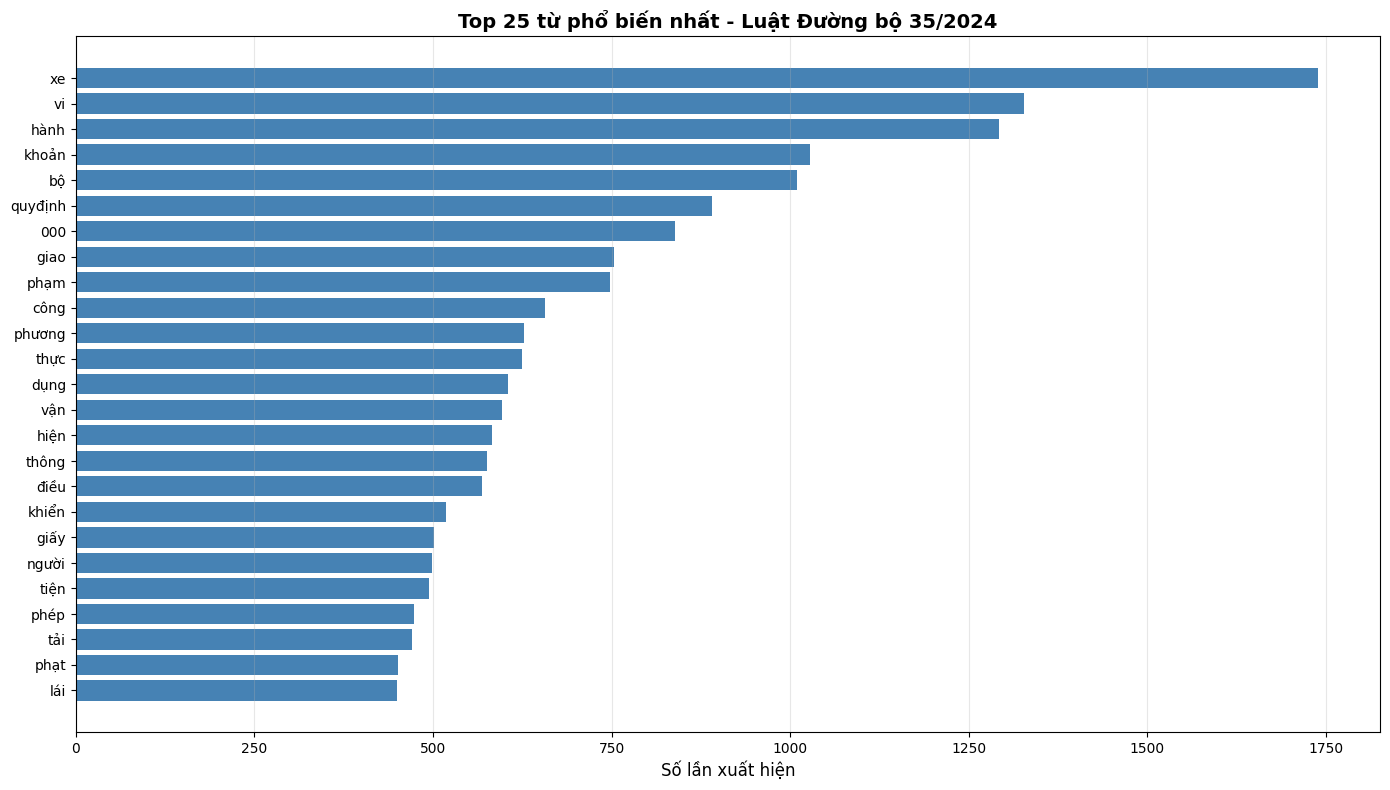

In [7]:
# Vẽ biểu đồ so sánh
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Luật Đường bộ
top_n = 25
ax.barh(range(top_n), law_word_freq.head(top_n)['count'], color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(law_word_freq.head(top_n)['word'])
ax.set_xlabel('Số lần xuất hiện', fontsize=12)
ax.set_title(f'Top {top_n} từ phổ biến nhất - Luật Đường bộ 35/2024', fontsize=14, weight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. N-grams Analysis - Phân tích cụm từ

In [8]:
# Bigrams cho Luật Đường bộ
law_bigram_vec = CountVectorizer(ngram_range=(2, 2), max_features=50)
law_bigram_matrix = law_bigram_vec.fit_transform(law_texts)
law_bigram_features = law_bigram_vec.get_feature_names_out()

# Thống kê bigrams
law_bigram_counts = np.asarray(law_bigram_matrix.sum(axis=0)).flatten()
law_bigram_freq = pd.DataFrame({
    'bigram': law_bigram_features, 
    'count': law_bigram_counts
})
law_bigram_freq = law_bigram_freq.sort_values('count', ascending=False)

print("="*70)
print("BIGRAMS - LUẬT ĐƯỜNG BỘ")
print("="*70)
print(law_bigram_freq.head(30))

BIGRAMS - LUẬT ĐƯỜNG BỘ
             bigram  count
43          vi phạm    640
15          hành vi    595
40        thực hiện    524
30      phương tiện    493
44            vi vi    447
20       khoản điều    408
45          vận tải    391
25           lái xe    387
10       giao thông    377
36          sử dụng    369
0           000 000    364
12        giấy phép    351
3           an toàn    335
13        hiện hành    332
42          tổ chức    303
46           xeô tô    261
1          000 đồng    245
29         phép lái    244
21       khoản điểm    235
41       trường hợp    234
11  giao thôngđường    233
18         khiển xe    225
22       kinh doanh    223
2       000 đồngđối    222
31        phạt tiền    222
35          quản lý    220
48          xử phạt    213
28        pháp luật    200
7        công trình    196
38    thôngđường bộ    196


In [9]:
# Trigrams cho Luật Đường bộ
law_trigram_vec = CountVectorizer(ngram_range=(3, 3), max_features=50)
law_trigram_matrix = law_trigram_vec.fit_transform(law_texts)
law_trigram_features = law_trigram_vec.get_feature_names_out()

law_trigram_counts = np.asarray(law_trigram_matrix.sum(axis=0)).flatten()
law_trigram_freq = pd.DataFrame({
    'trigram': law_trigram_features,
    'count': law_trigram_counts
})
law_trigram_freq = law_trigram_freq.sort_values('count', ascending=False)

print("="*70)
print("TRIGRAMS - LUẬT ĐƯỜNG BỘ")
print("="*70)
print(law_trigram_freq.head(30))

TRIGRAMS - LUẬT ĐƯỜNG BỘ
                   trigram  count
16              hành vi vi    447
45              vi vi phạm    438
33          thực hiện hành    328
14            hiện hành vi    327
13           giấy phép lái    244
26             phép lái xe    226
12      giao thôngđường bộ    194
1          000 000 đồngđối    181
20          kinh doanh vận    179
0             000 000 đồng    177
10           doanh vận tải    173
18       khiển phương tiện    150
7        chứng nhậnđăng ký    144
4             an toàn giao    143
25          nhậnđăng ký xe    140
21              kết cấu hạ    128
32           tham gia giao    127
9         cấu hạ tầngđường    127
42            vi phạm hành    119
17         hạ tầngđường bộ    111
30       quyđịnh pháp luật    107
38       trừđiểm giấy phép    107
43         vi phạm quyđịnh    100
29      quyđịnh khoản điều     99
2             000 đồng 000     99
44     vi phạm quyđịnhđiểm     99
49            đồng 000 000     99
19        khoản điểm kh

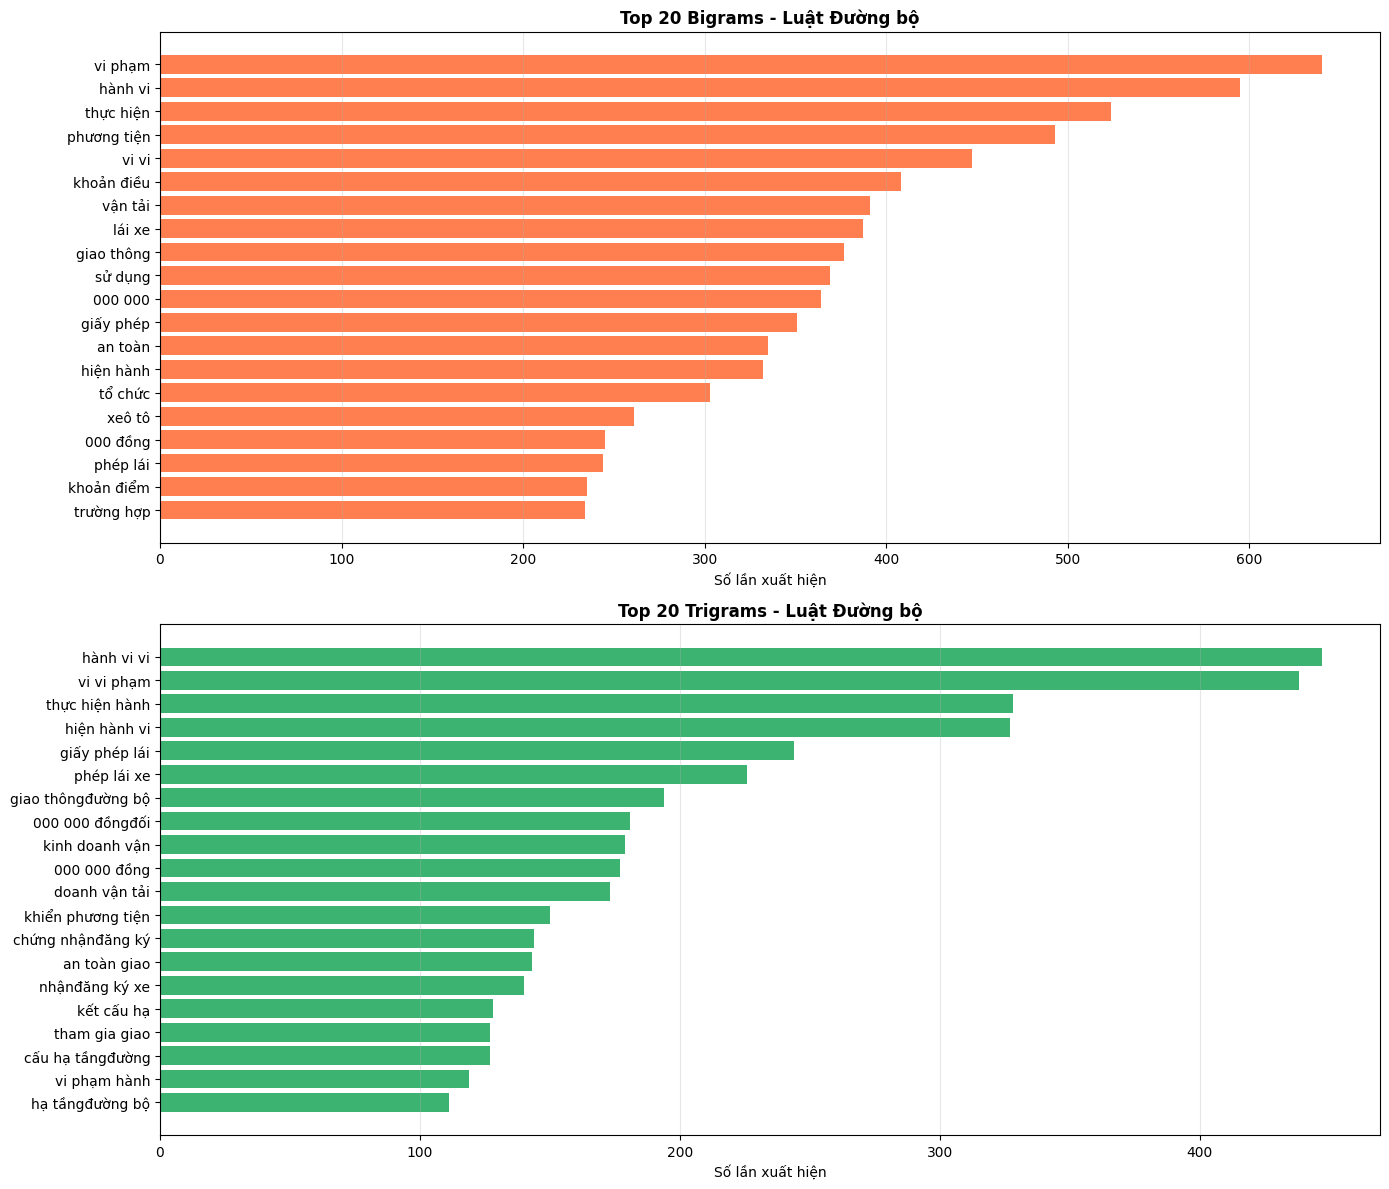

In [10]:
# Vẽ biểu đồ N-grams
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Bigrams
top_n = 20
axes[0].barh(range(top_n), law_bigram_freq.head(top_n)['count'], color='coral')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(law_bigram_freq.head(top_n)['bigram'])
axes[0].set_xlabel('Số lần xuất hiện')
axes[0].set_title(f'Top {top_n} Bigrams - Luật Đường bộ', fontsize=12, weight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Trigrams
axes[1].barh(range(top_n), law_trigram_freq.head(top_n)['count'], color='mediumseagreen')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(law_trigram_freq.head(top_n)['trigram'])
axes[1].set_xlabel('Số lần xuất hiện')
axes[1].set_title(f'Top {top_n} Trigrams - Luật Đường bộ', fontsize=12, weight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Co-occurrence Matrix - Ma trận đồng xuất hiện

In [11]:
def build_cooccurrence_matrix(texts, window_size=3, top_words=40):
    """
    Xây dựng ma trận đồng xuất hiện từ danh sách văn bản
    """
    # Đếm tần suất từ
    word_counter = Counter()
    for text in texts:
        word_counter.update(text.split())
    
    # Lấy top words
    top_word_list = [word for word, _ in word_counter.most_common(top_words)]
    word_to_idx = {word: idx for idx, word in enumerate(top_word_list)}
    
    # Khởi tạo ma trận
    cooc_matrix = np.zeros((top_words, top_words))
    
    # Đếm đồng xuất hiện
    for text in texts:
        words = text.split()
        for i, word in enumerate(words):
            if word not in word_to_idx:
                continue
            
            start = max(0, i - window_size)
            end = min(len(words), i + window_size + 1)
            
            for j in range(start, end):
                if i != j and words[j] in word_to_idx:
                    cooc_matrix[word_to_idx[word]][word_to_idx[words[j]]] += 1
    
    return cooc_matrix, top_word_list

# Xây dựng ma trận cho Luật Đường bộ
print("Đang xây dựng ma trận đồng xuất hiện cho Luật Đường bộ...")
law_cooc_matrix, law_top_words = build_cooccurrence_matrix(
    law_texts[:50],  # Lấy 50 văn bản đầu
    window_size=3, 
    top_words=40
)

print(f"\nKích thước ma trận: {law_cooc_matrix.shape}")
print(f"Top 40 từ phân tích: {law_top_words}")

Đang xây dựng ma trận đồng xuất hiện cho Luật Đường bộ...

Kích thước ma trận: (40, 40)
Top 40 từ phân tích: ['bộ', 'công', 'giao', 'thông', 'quyđịnh', 'bảo', 'quản', 'trình', 'an', 'hành', 'lý', 'khai', 'tư', 'kết', 'xây', 'vận', 'thác', 'pháp', 'dựng', 'sử', 'toàn', 'luật', 'hạ', 'phương', 'cao', 'cấu', 'cấp', 'tầngđường', 'bảođảm', 'hiện', 'thực', 'thôngđường', 'khác', 'quan', 'dụng', 'báo', 'cơ', 'trìnhđường', 'quy', 'vệ']


In [12]:
# Tạo DataFrame và vẽ heatmap
df_law_cooc = pd.DataFrame(
    law_cooc_matrix, 
    index=law_top_words, 
    columns=law_top_words
)

print("Ma trận đồng xuất hiện (15x15 đầu tiên):")
print(df_law_cooc.iloc[:15, :15])

Ma trận đồng xuất hiện (15x15 đầu tiên):
            bộ   công   giao  thông  quyđịnh   bảo   quản  trình    an  hành     lý  khai    tư   kết   xây
bộ        86.0  159.0  154.0   38.0     51.0  44.0   44.0   51.0  62.0  23.0   32.0  44.0  20.0  26.0  35.0
công     159.0   64.0   10.0   22.0     20.0  37.0    8.0  208.0  51.0  15.0   12.0  37.0  58.0  11.0  59.0
giao     154.0   10.0    2.0  215.0     13.0   3.0   30.0   13.0  82.0  22.0   15.0   6.0   2.0  12.0   4.0
thông     38.0   22.0  215.0   66.0     20.0   4.0   13.0    5.0  60.0  21.0   18.0   2.0   2.0   9.0   3.0
quyđịnh   51.0   20.0   13.0   20.0     44.0   4.0    9.0   15.0  11.0   1.0    5.0   5.0  23.0   3.0  21.0
bảo       44.0   37.0    3.0    4.0      4.0  90.0    7.0   21.0   2.0  56.0    6.0  41.0   0.0  45.0   1.0
quản      44.0    8.0   30.0   13.0      9.0   7.0    4.0    3.0   0.0  72.0  171.0   8.0  11.0   3.0  12.0
trình     51.0  208.0   13.0    5.0     15.0  21.0    3.0    8.0  29.0   9.0    2.0  14.0   2.0

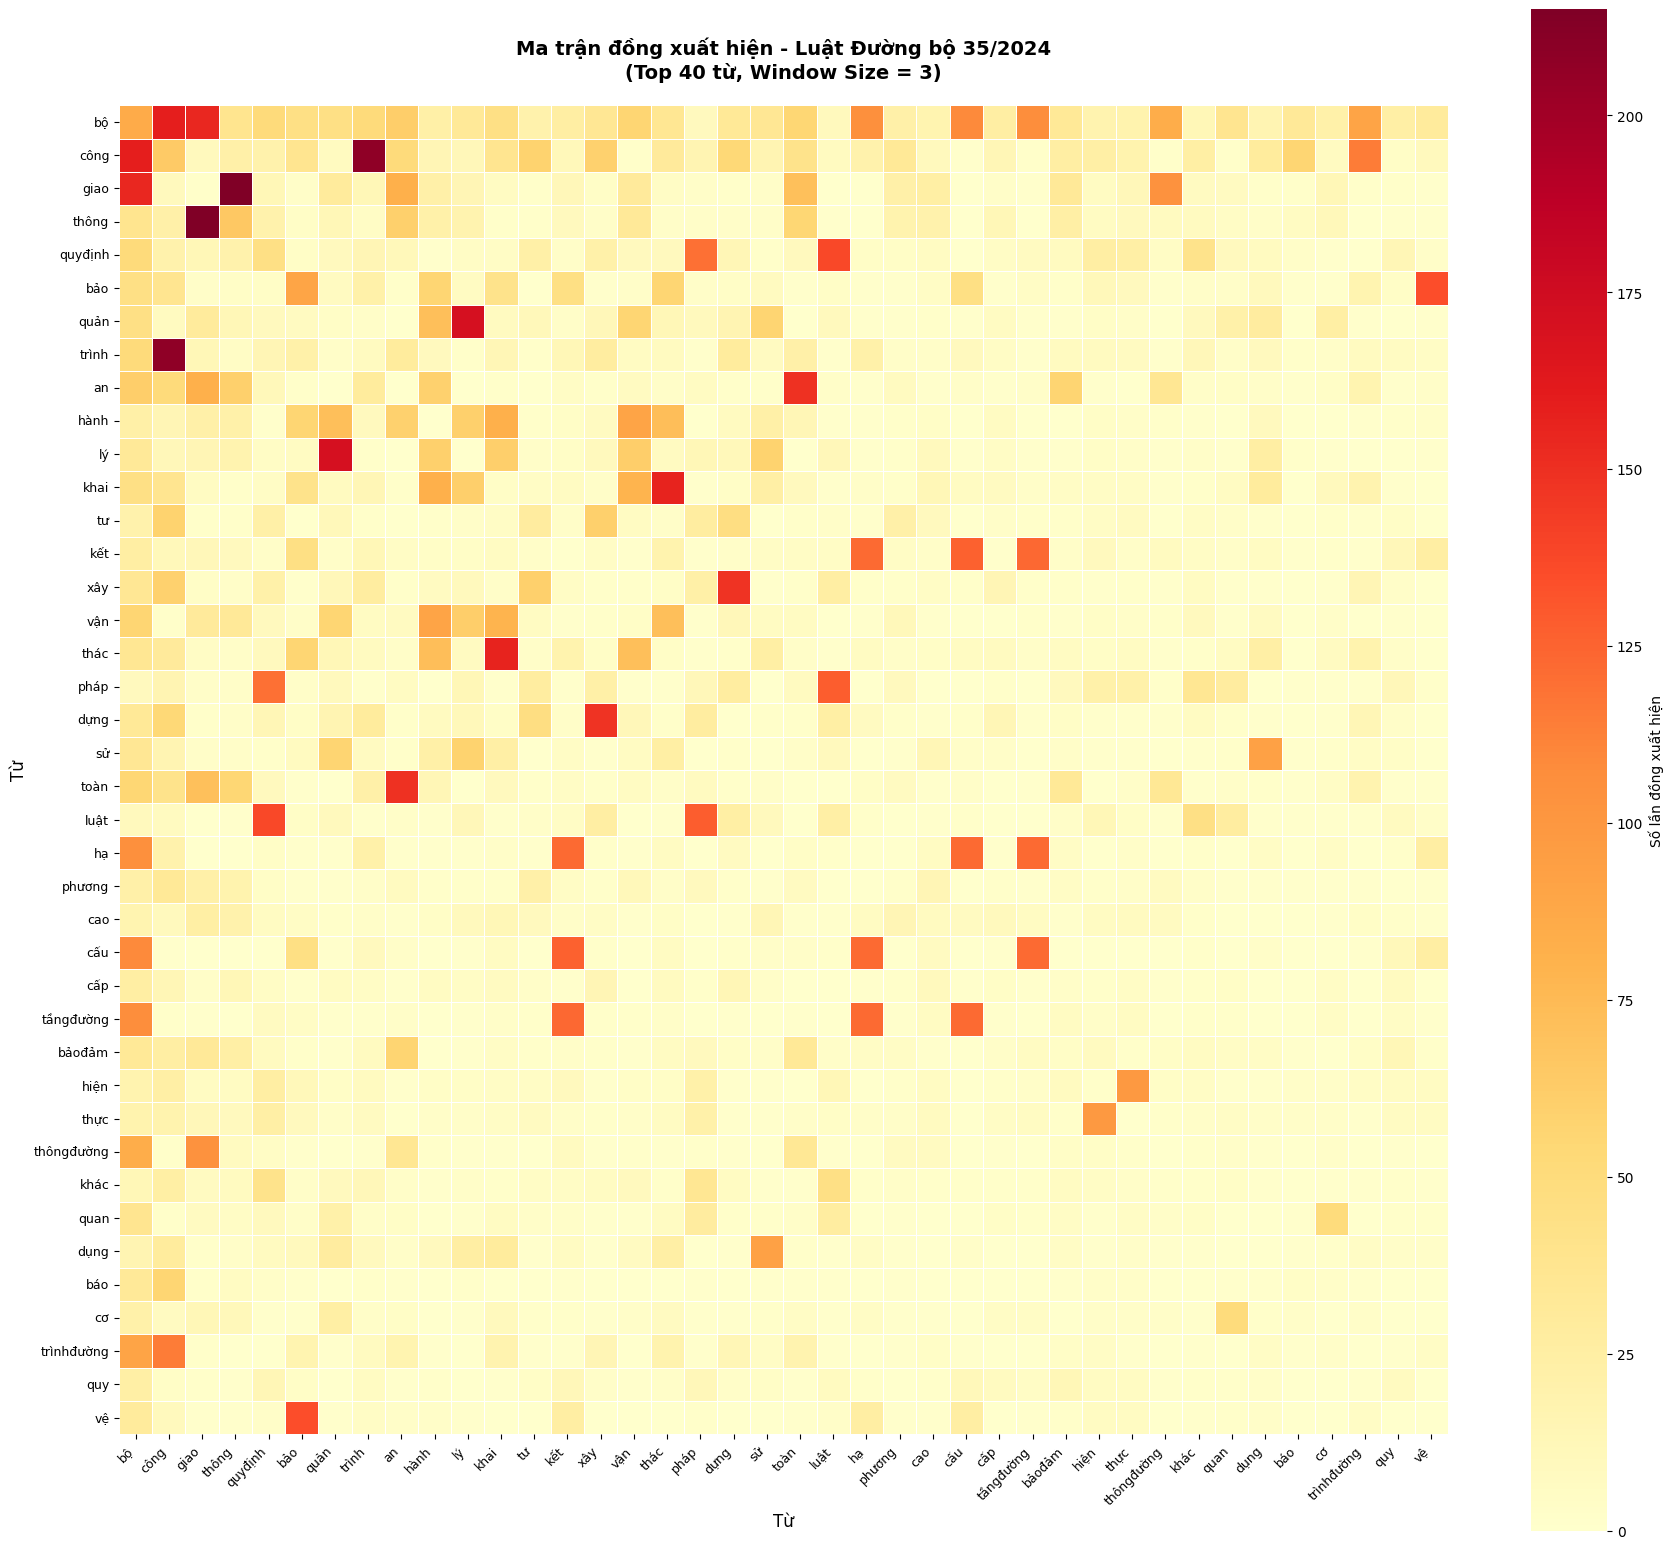

In [13]:
# Vẽ heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(
    df_law_cooc,
    annot=False,
    cmap='YlOrRd',
    square=True,
    cbar_kws={'label': 'Số lần đồng xuất hiện'},
    linewidths=0.5,
    linecolor='white'
)
plt.title('Ma trận đồng xuất hiện - Luật Đường bộ 35/2024\n(Top 40 từ, Window Size = 3)', 
          fontsize=14, weight='bold', pad=20)
plt.xlabel('Từ', fontsize=12)
plt.ylabel('Từ', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [14]:
# Phân tích từ liên quan
def find_related_words(target_word, cooc_matrix, word_list, top_n=10):
    """Tìm các từ thường đi kèm với từ mục tiêu"""
    if target_word not in word_list:
        print(f"Từ '{target_word}' không có trong danh sách")
        return
    
    idx = word_list.index(target_word)
    cooc_scores = cooc_matrix[idx]
    
    related_indices = np.argsort(cooc_scores)[::-1][:top_n]
    
    print(f"\nTop {top_n} từ thường đi kèm với '{target_word}':")
    print("-" * 60)
    for i, idx in enumerate(related_indices, 1):
        if cooc_scores[idx] > 0:
            print(f"{i:2d}. {word_list[idx]:20s} - {int(cooc_scores[idx]):4d} lần")

# Phân tích một số từ khóa quan trọng
keywords = ['đường', 'giao', 'xe', 'bộ', 'quyđịnh', 'luật']

print("="*70)
print("PHÂN TÍCH TỪ LIÊN QUAN - LUẬT ĐƯỜNG BỘ")
print("="*70)

for keyword in keywords:
    find_related_words(keyword, law_cooc_matrix, law_top_words, top_n=8)

PHÂN TÍCH TỪ LIÊN QUAN - LUẬT ĐƯỜNG BỘ
Từ 'đường' không có trong danh sách

Top 8 từ thường đi kèm với 'giao':
------------------------------------------------------------
 1. thông                -  215 lần
 2. bộ                   -  154 lần
 3. thôngđường           -  104 lần
 4. an                   -   82 lần
 5. toàn                 -   71 lần
 6. bảođảm               -   32 lần
 7. vận                  -   31 lần
 8. quản                 -   30 lần
Từ 'xe' không có trong danh sách

Top 8 từ thường đi kèm với 'bộ':
------------------------------------------------------------
 1. công                 -  159 lần
 2. giao                 -  154 lần
 3. cấu                  -  109 lần
 4. tầngđường            -  107 lần
 5. hạ                   -  105 lần
 6. trìnhđường           -   91 lần
 7. bộ                   -   86 lần
 8. thôngđường           -   84 lần

Top 8 từ thường đi kèm với 'quyđịnh':
------------------------------------------------------------
 1. luật                

## 6. TF-IDF - Trọng số từ quan trọng

In [15]:
# TF-IDF cho Luật Đường bộ
tfidf_vectorizer = TfidfVectorizer(max_features=50)
law_tfidf_matrix = tfidf_vectorizer.fit_transform(law_texts)
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print("="*70)
print("TF-IDF VECTORIZING - LUẬT ĐƯỜNG BỘ")
print("="*70)
print(f"Kích thước ma trận: {law_tfidf_matrix.shape}")

# Tính điểm TF-IDF trung bình cho mỗi từ
tfidf_scores = np.asarray(law_tfidf_matrix.mean(axis=0)).flatten()
tfidf_df = pd.DataFrame({
    'word': tfidf_features,
    'tfidf_score': tfidf_scores
})
tfidf_df = tfidf_df.sort_values('tfidf_score', ascending=False)

print("\nTop 30 từ quan trọng nhất theo TF-IDF:")
print(tfidf_df.head(30))

TF-IDF VECTORIZING - LUẬT ĐƯỜNG BỘ
Kích thước ma trận: (157, 50)

Top 30 từ quan trọng nhất theo TF-IDF:
       word  tfidf_score
45       xe     0.216771
3        bộ     0.177807
42       vi     0.158187
0       000     0.153839
14     hành     0.138015
6      công     0.128634
17    khoản     0.124126
28  quyđịnh     0.116510
10     giao     0.109685
43      vận     0.103317
16    khiển     0.091469
26     phạm     0.091311
40      tải     0.089091
33    thông     0.085767
25   phương     0.083582
19     luật     0.076465
9      dụng     0.076139
48     điều     0.075138
34     thực     0.074059
12     hiện     0.072396
11     giấy     0.072106
20      lái     0.070547
27     phạt     0.069784
13     hàng     0.069752
49     điểm     0.069210
35     tiện     0.068586
37    trình     0.068567
22    người     0.067457
7        cơ     0.067437
1        an     0.067242


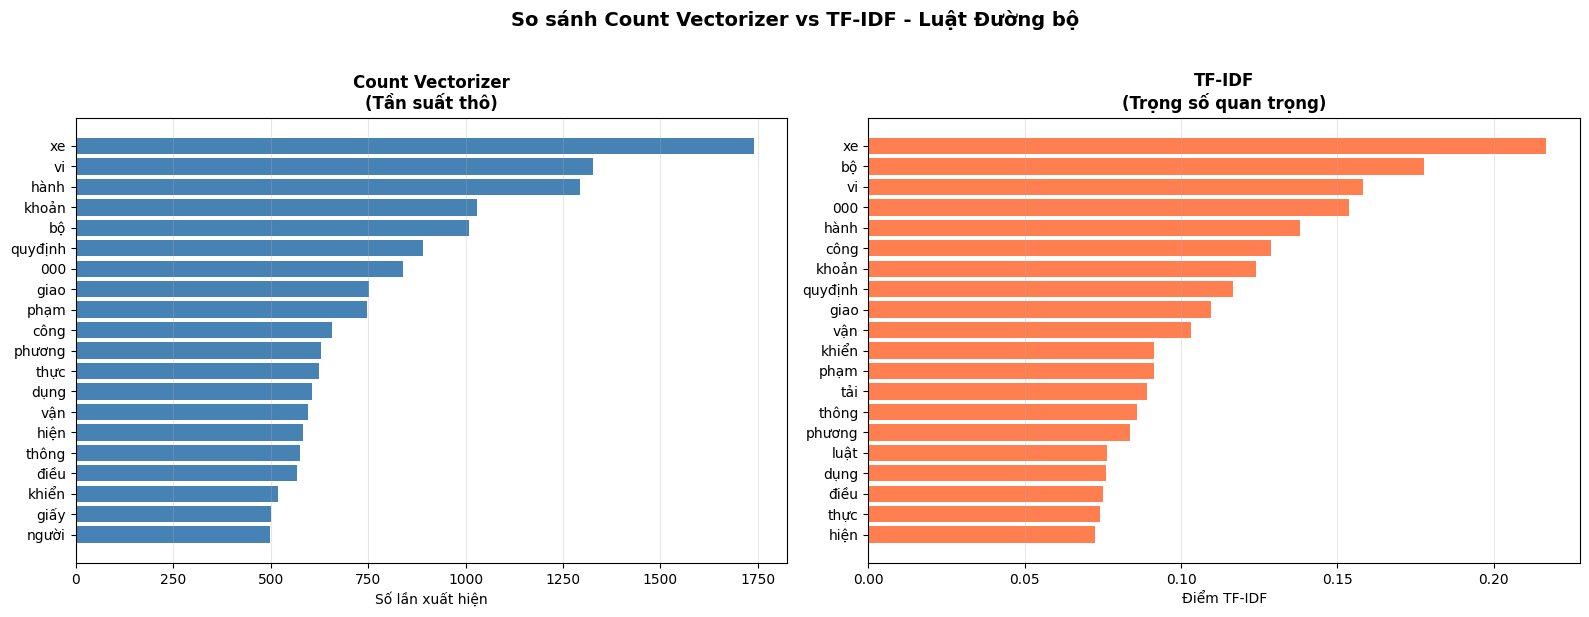

In [16]:
# So sánh Count vs TF-IDF
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_n = 20

# Count Vectorizer
axes[0].barh(range(top_n), law_word_freq.head(top_n)['count'], color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(law_word_freq.head(top_n)['word'])
axes[0].set_xlabel('Số lần xuất hiện')
axes[0].set_title('Count Vectorizer\n(Tần suất thô)', fontsize=12, weight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# TF-IDF
axes[1].barh(range(top_n), tfidf_df.head(top_n)['tfidf_score'], color='coral')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(tfidf_df.head(top_n)['word'])
axes[1].set_xlabel('Điểm TF-IDF')
axes[1].set_title('TF-IDF\n(Trọng số quan trọng)', fontsize=12, weight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('So sánh Count Vectorizer vs TF-IDF - Luật Đường bộ', 
             fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Phân tích so sánh Window Size trong Co-occurrence Matrix

SO SÁNH CÁC WINDOW SIZE
Window size = 1: Tổng = 3,354, Trung bình = 12.61
Window size = 2: Tổng = 6,378, Trung bình = 12.31
Window size = 3: Tổng = 8,760, Trung bình = 13.02
Window size = 5: Tổng = 13,460, Trung bình = 16.33
Window size = 7: Tổng = 18,168, Trung bình = 20.60


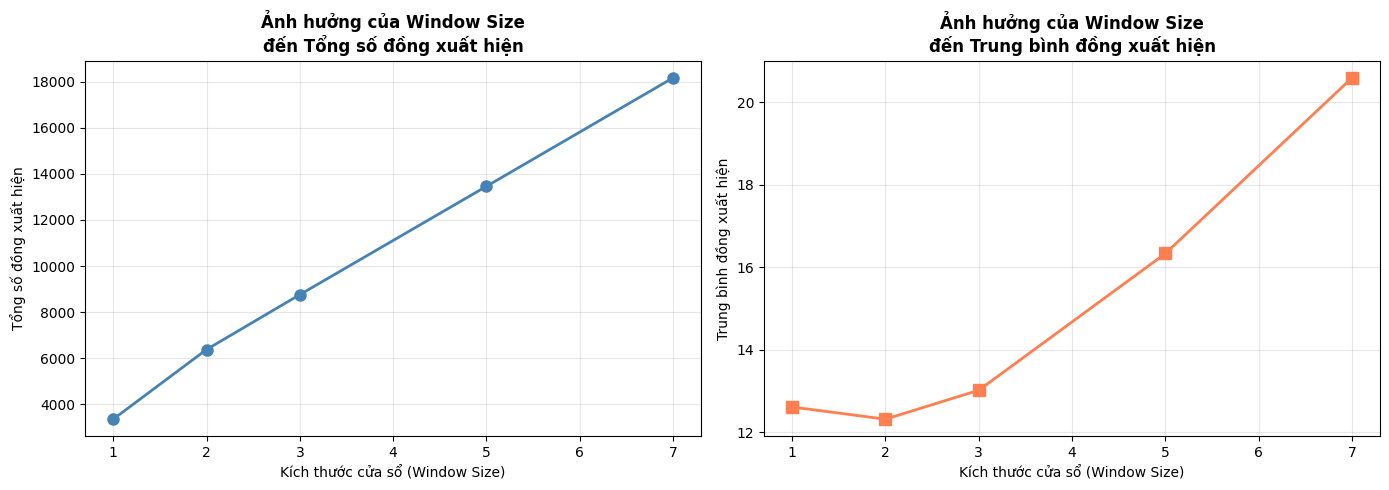

In [17]:
# So sánh các window size khác nhau
print("="*70)
print("SO SÁNH CÁC WINDOW SIZE")
print("="*70)

window_sizes = [1, 2, 3, 5, 7]
results = []

for window in window_sizes:
    cooc_temp, _ = build_cooccurrence_matrix(
        law_texts[:30], 
        window_size=window, 
        top_words=30
    )
    total_cooc = int(np.sum(cooc_temp))
    avg_cooc = np.mean(cooc_temp[cooc_temp > 0]) if np.any(cooc_temp > 0) else 0
    
    results.append({
        'window_size': window,
        'total_cooccurrences': total_cooc,
        'average_cooccurrence': avg_cooc
    })
    
    print(f"Window size = {window}: Tổng = {total_cooc:,}, Trung bình = {avg_cooc:.2f}")

# Vẽ biểu đồ
df_results = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_results['window_size'], df_results['total_cooccurrences'], 
            marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Kích thước cửa sổ (Window Size)')
axes[0].set_ylabel('Tổng số đồng xuất hiện')
axes[0].set_title('Ảnh hưởng của Window Size\nđến Tổng số đồng xuất hiện', weight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_results['window_size'], df_results['average_cooccurrence'],
            marker='s', linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('Kích thước cửa sổ (Window Size)')
axes[1].set_ylabel('Trung bình đồng xuất hiện')
axes[1].set_title('Ảnh hưởng của Window Size\nđến Trung bình đồng xuất hiện', weight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Tổng kết và So sánh các phương pháp

### Bảng so sánh:

| Phương pháp | Độ phức tạp | Kích thước ma trận | Ưu điểm | Nhược điểm |
|-------------|-------------|-------------------|---------|------------|
| **One-Hot** | O(V) | Rất lớn, thưa | Đơn giản | Không thể hiện ngữ nghĩa |
| **Count** | O(N×V) | Vừa phải | Bảo toàn tần suất | Bị ảnh hưởng độ dài |
| **TF-IDF** | O(N×V) | Vừa phải | Phân biệt từ quan trọng | Phức tạp tính toán |
| **N-grams** | O(N×V^n) | Rất lớn | Giữ ngữ cảnh | Tăng chiều nhanh |
| **Co-occurrence** | O(N×W×V) | V×V | Quan hệ từ | Tốn bộ nhớ |

Trong đó:
- V = kích thước từ vựng
- N = số văn bản
- W = window size
- n = kích thước n-gram